In [31]:
import pandas  as pd
import glob
pd.set_option('display.max_rows', 1000)
pd.set_option('display.max_columns', 400)

In [32]:
paths = glob.glob('/mnt/c/Users/Acer/Downloads/samu_dateset/*.csv')

In [33]:
paths

['/mnt/c/Users/Acer/Downloads/samu_dateset/ocorrenciassamu2022.csv',
 '/mnt/c/Users/Acer/Downloads/samu_dateset/ocorrenciassamu2023.csv',
 '/mnt/c/Users/Acer/Downloads/samu_dateset/ocorrenciassamu2024.csv',
 '/mnt/c/Users/Acer/Downloads/samu_dateset/ocorrenciassamu2025.csv']

In [62]:
def format_hora_minuto(x):
    if pd.isna(x):
        return x
    try:
        pt1 = x.split(':')[0].zfill(2)
        pt2 = x.split(':')[1].zfill(2)
    except:
        import ipdb;ipdb.set_trace()
        
    return pt1 + ':' + pt2

df_all = pd.DataFrame()
for p in paths:
    df = pd.read_csv(p, sep=';', dtype=str)
    df['data'] = pd.to_datetime(df['data'])
    df['hora_minuto'] = df['hora_minuto'].apply(lambda x: format_hora_minuto(x))

    df['origem_chamado'] = df['origem_chamado'].replace(
        {'RESIDENCIAL': 'RESIDENC', 
         'VIA PÚBLICA':'VIA PUBL', 
         'UNIDADE DE SAÚDE': 'UNIDADE',
         'ANI / AL ': 'ANI/ALI '}
    )
    df_all =  pd.concat([df_all, df.drop_duplicates()])

In [64]:
df_all.head() # CASO SUSPEITO COVID-19 e COVID

,data,hora_minuto,municipio,bairro,endereco,origem_chamado,tipo,subtipo,sexo,idade,motivo_finalizacao,motivo_desfecho
0,2022-01-01,00:02,RECIFE,JARDIM SAO PAULO,R LEANDRO BARRETO,RESIDENC,RESPIRATORIA,CASO SUSPEITO COVID-19,FEMININO,81,NaN,PACIENTE RECUSA SER REMOVIDO
1,2022-01-01,00:03,RECIFE,MADALENA,R ALTINHO,RESIDENC,CAUSAS EXTERNAS,QUEDA DA PROPRIA ALTURA,FEMININO,81,NaN,DESISTÊNCIA DA SOLICITAÇÃO
2,2022-01-01,00:09,MACAPARANA,CENTRO,R POSSIDONIO JULIAO DA SILVA,VIA PUBL,CAUSAS EXTERNAS,OUTROS,MASCULINO,0,REGULAÇÃO POR TELEFONE,SEM DESFECHO
3,2022-01-01,00:10,VITORIA DE SANTO ANTAO,CENTRO,RUA JOSE COSTA N 93 BAIRRO DA,RESIDENC,GERAIS/OUTROS,OUTROS,FEMININO,NaN,DESISTÊNCIA DA SOLICITAÇÃO,SEM DESFECHO
4,2022-01-01,00:12,PALMARES,PALMARES CENTRO,RUA DOUTOR COSTA MAIA,RESIDENC,GERAIS/OUTROS,OUTROS,MASCULINO,84,NaN,OCORRÊNCIA CONCLUÍDA COM ÊXITO


In [65]:
df_all['municipio'].value_counts().head()

municipio
RECIFE                     269819
JABOATAO DOS GUARARAPES     76997
OLINDA                      52846
PAULISTA                    45750
CABO DE SANTO AGOSTINHO     20457
Name: count, dtype: int64

In [66]:
df_all['day'] = df_all['data'].dt.day
df_all['year'] = df_all['data'].dt.year
df_all['month'] = df_all['data'].dt.month

In [75]:
df_sample = df_all[(
    (~df_all['subtipo'].str.contains('COVID', case=True, na=False)) & 
    (~df_all['motivo_finalizacao'].str.contains('DUPLICADA', case=True, na=False))&
    (df_all['municipio'].isin(['RECIFE'])) & 
    #(df_all['motivo_finalizacao'] == 'REGULAÇÃO POR TELEFONE') &
    (df_all['data']>='2022-06-01')
)].copy()

In [76]:
df_agg = df_sample.groupby('data')[['hora_minuto']].count()

In [77]:
df_agg = df_agg.reset_index()
df_joined = pd.DataFrame({'data': pd.date_range(df_agg['data'].min(), df_agg['data'].max(), freq='D')}
            ).merge(df_agg, on=['data'], how='left')# garantir que tem info todos os dias

<Axes: xlabel='data'>

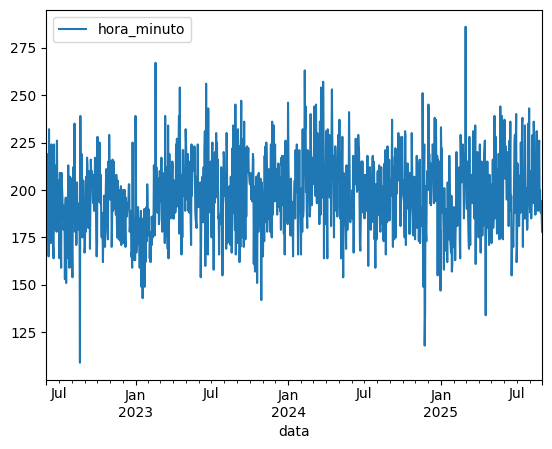

In [78]:
df_joined.set_index('data').plot()

In [84]:
df_joined.shape

(1188, 2)

In [85]:
df_joined

,data,hora_minuto
0,2022-06-01,183
1,2022-06-02,194
2,2022-06-03,180
3,2022-06-04,200
4,2022-06-05,174
...,...,...
1183,2025-08-27,191
1184,2025-08-28,188
1185,2025-08-29,194
1186,2025-08-30,186


In [79]:
df_mean = df_joined['hora_minuto'].rolling(window=7, min_periods=1).mean().iloc[7:]

<Axes: >

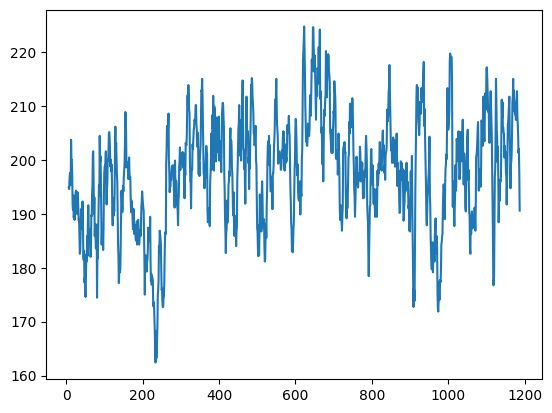

In [80]:
import numpy as np
df_mean.plot()

In [83]:
df_mean.shape

(1181,)

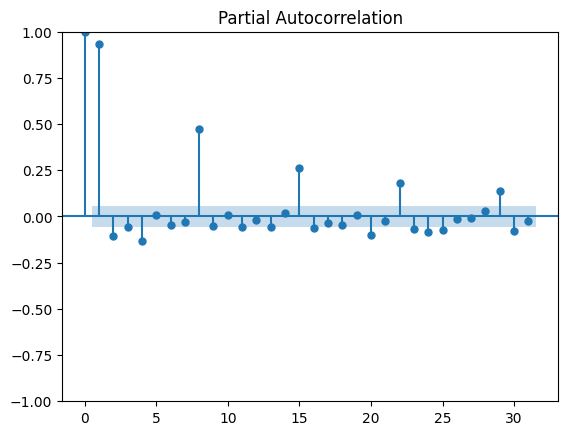

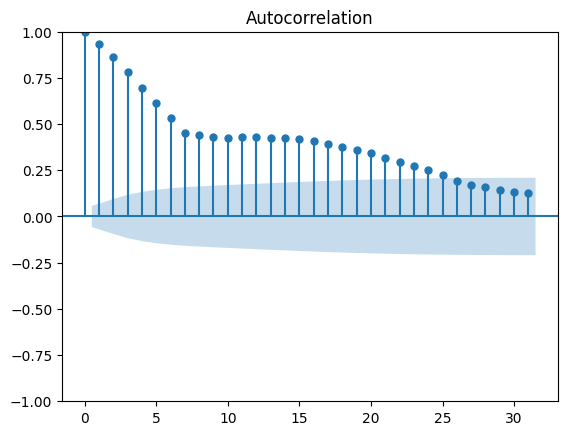

In [82]:
from statsmodels.graphics.tsaplots import plot_pacf, plot_acf
import matplotlib.pyplot as plt

plot_pacf(df_mean.iloc[1:])
plt.show()
plot_acf(df_mean.iloc[1:])
plt.show()

,hora_minuto
7,507.857143
8,507.714286
9,517.571429
10,513.142857
11,507.857143
...,...
1183,531.428571
1184,531.571429
1185,530.000000
1186,518.428571


In [41]:
pd.DataFrame(df_mean).rename(columns={'hora_minuto': 'y'})['y'].to_csv('masamu.txt', index=False)

In [16]:
df_joined.rename(columns={'hora_minuto': 'y'})['y'].to_csv('samurec.txt', index=False)

In [12]:
df_sample['motivo_finalizacao'].value_counts(dropna=False, normalize= True)

motivo_finalizacao
NaN                                                      0.713131
REGULAÇÃO POR TELEFONE                                   0.156112
DESISTÊNCIA DA SOLICITAÇÃO                               0.098620
REMOVIDO ANTES DO ATENDIMENTO POR PARTICULARES           0.024770
REMOVIDO PELOS BOMBEIROS/CIODS                           0.004342
PACIENTE JÉ ENCONTRADO EM ÓBITO                          0.002351
CANCELADA                                                0.000441
CANCELADA                                                0.000164
PACIENTE SEM CONDIÇÕES CLÍNICAS DE REMOÇÃO HOSPITALAR    0.000030
78                                                       0.000013
67                                                       0.000010
74                                                       0.000003
43                                                       0.000003
63                                                       0.000003
19                                                       

In [14]:
df_all[pd.isna(df_all['motivo_finalizacao'])]['motivo_desfecho'].value_counts()

motivo_desfecho
OCORRÊNCIA CONCLUÍDA COM ÊXITO                                  211658
1. OCORRÊNCIA CONCLUÍDA COM ÊXITO                               146571
Ocorrncia concluda com xito                                     127625
Ocorrência concluída com êxito                                   60015
Removido antes do atendimento por particulares                   43625
REMOVIDO ANTES DO ATENDIMENTO POR PARTICULARES                   38577
sem desfecho                                                     33133
PACIENTE RECUSA SER REMOVIDO                                     31107
5. REMOVIDO ANTES DO ATENDIMENTO POR PARTICULARES                30419
4. DESISTÊNCIA DA SOLICITAÇÃO/ SEM CONTATO COM O SOLICITANTE     27744
DESISTÊNCIA DA SOLICITAÇÃO                                       27096
Paciente recusa ser removido                                     24208
7. PACIENTE RECUSA SER REMOVIDO                                  19496
Desistncia da solicitao                                      